# Analiza danych - kwiaty irysy


## O Danych

Zbiór danych zawiera informacje o trzech gatunkach irysów: Iris setosa, Iris versicolor, i Iris virginica.

Dane obejmują pomiary czterech cech: długość i szerokość działki kielicha oraz długość i szerokość płatka.

Każdy wiersz w zbiorze danych reprezentuje pojedynczy kwiat, a wartości pomiarów są podane w centymetrach.

Zbiór składa się z 150 próbek, po 50 dla każdego gatunku, i jest szeroko stosowany jako podstawowy zbiór danych do
testowania algorytmów klasyfikacji oraz w nauce o danych i uczeniu maszynowym.

Kolumny:
* **długość kielicha (sepal length)** - Długość kielicha w cm
* **szerokość kielicha (sepal width)** - Szerokość kielicha w cm
* **długość płatka (petal length)** - Długość płatka w cm
* **szerokość płatka (petal width)** - Szerokość płatka w cm
* **klasa (class)** - Klasa irysa (setosa, versicolor, virginica)

In [1]:
import pandas as pd
from IPython.display import Markdown

## Przykładowe dane ze zbioru:

In [2]:
df = pd.read_csv('25__iris.csv', sep=",")
df.sample(10)

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width),klasa (class)
134,6.1,2.6,5.6,1.4,Iris-virginica
71,6.1,2.8,4.0,1.3,Iris-versicolor
59,5.2,2.7,3.9,1.4,Iris-versicolor
110,6.5,3.2,5.1,2.0,Iris-virginica
89,5.5,2.5,4.0,1.3,Iris-versicolor
56,6.3,3.3,4.7,1.6,Iris-versicolor
81,5.5,2.4,3.7,1.0,Iris-versicolor
13,4.3,3.0,1.1,0.1,Iris-setosa
39,5.1,3.4,1.5,0.2,Iris-setosa
38,4.4,3.0,1.3,0.2,Iris-setosa


# Analiza trzech gatunków Irysów

## Poniżej krótki opis roślin

#### Irys, Kosaciec(Iris L.) – rodzaj roślin należący do rodziny kosaćcowatych. Obejmuje co najmniej 311 gatunków. Zasięg rodzaju obejmuje wszystkie kontynenty na półkuli północnej, najbardziej zróżnicowany jest tu w strefie umiarkowanej. Najdalej na południe sięga północnego Meksyku, Jemenu i Filipin. W Ameryce Północnej obecne są 34 gatunki, w Europie 31, w Chinach co najmniej 58. Do flory Polski należą cztery gatunki: kosaciec bezlistny I. aphylla, trawolistny I. graminea, żółty I. pseudacorus i syberyjski I. sibirica.



[Link do źródła - Wikipedii](https://pl.wikipedia.org/wiki/Kosaciec)

 ![Budowa Irysa](https://irysowyzakatek.wordpress.com/wp-content/uploads/2015/06/obraz-budowa-kwiatu-irysa.png)

In [3]:
df.columns

Index(['długość kielicha (sepal length)', 'szerokość kielicha (sepal width)',
       'długość płatka (petal length)', 'szerokość płatka (petal width)',
       'klasa (class)'],
      dtype='object')

In [4]:
# Zmieniłem nazwy na skrócone i polskie, żeby przejrzyściej wyglądały wykresy i tabele. 
# Dodatkowo ustawiłem klase kwiata na pierwszym miejscu

df = df.rename(columns={'długość kielicha (sepal length)': 'dł_kielicha', 'szerokość kielicha (sepal width)': 'szer_kielicha', 'długość płatka (petal length)': 'dł_płatka', 'szerokość płatka (petal width)': 'szer_płatka'})

df = df[['klasa (class)', 'dł_kielicha', 'szer_kielicha', 'dł_płatka', 'szer_płatka']]

df

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
0,Iris-setosa,5.1,3.5,1.4,0.2
1,Iris-setosa,4.9,3.0,1.4,0.2
2,Iris-setosa,4.7,3.2,1.3,0.2
3,Iris-setosa,4.6,3.1,1.5,0.2
4,Iris-setosa,5.0,3.6,1.4,0.2
...,...,...,...,...,...
145,Iris-virginica,6.7,3.0,5.2,2.3
146,Iris-virginica,6.3,2.5,5.0,1.9
147,Iris-virginica,6.5,3.0,5.2,2.0
148,Iris-virginica,6.2,3.4,5.4,2.3


In [5]:
# Na początek sprawdziłem dane kilkoma podstawowymi komenadami:
# df.head(), df.tail(), df.sample(), df.info(), df.describe(), df.nunique()

df.head(7)

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
0,Iris-setosa,5.1,3.5,1.4,0.2
1,Iris-setosa,4.9,3.0,1.4,0.2
2,Iris-setosa,4.7,3.2,1.3,0.2
3,Iris-setosa,4.6,3.1,1.5,0.2
4,Iris-setosa,5.0,3.6,1.4,0.2
5,Iris-setosa,5.4,3.9,1.7,0.4
6,Iris-setosa,4.6,3.4,1.4,0.3


In [6]:
df.tail(7)

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
143,Iris-virginica,6.8,3.2,5.9,2.3
144,Iris-virginica,6.7,3.3,5.7,2.5
145,Iris-virginica,6.7,3.0,5.2,2.3
146,Iris-virginica,6.3,2.5,5.0,1.9
147,Iris-virginica,6.5,3.0,5.2,2.0
148,Iris-virginica,6.2,3.4,5.4,2.3
149,Iris-virginica,5.9,3.0,5.1,1.8


In [7]:
df.sample(10)

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
146,Iris-virginica,6.3,2.5,5.0,1.9
97,Iris-versicolor,6.2,2.9,4.3,1.3
13,Iris-setosa,4.3,3.0,1.1,0.1
35,Iris-setosa,5.0,3.2,1.2,0.2
68,Iris-versicolor,6.2,2.2,4.5,1.5
95,Iris-versicolor,5.7,3.0,4.2,1.2
33,Iris-setosa,5.5,4.2,1.4,0.2
139,Iris-virginica,6.9,3.1,5.4,2.1
105,Iris-virginica,7.6,3.0,6.6,2.1
136,Iris-virginica,6.3,3.4,5.6,2.4


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   klasa (class)  150 non-null    object 
 1   dł_kielicha    150 non-null    float64
 2   szer_kielicha  150 non-null    float64
 3   dł_płatka      150 non-null    float64
 4   szer_płatka    150 non-null    float64
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## Opis statystyczny zbioru danych

In [9]:
df.describe()

# Opis statystyczny całej próbki kwiatów

,dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
df.nunique()

klasa (class)     3
dł_kielicha      35
szer_kielicha    23
dł_płatka        43
szer_płatka      22
dtype: int64

In [11]:
df.isnull().sum()

# Nie ma brakujących wartości w wierszach i kolumnach

klasa (class)    0
dł_kielicha      0
szer_kielicha    0
dł_płatka        0
szer_płatka      0
dtype: int64

In [12]:
df[df.duplicated()]

# Kilka pozycji wygląda na zduplkiowane, ale nie usuwam. Każdego kwiatu było po 50 sztuk. Niektóre mogą wyglądać podobnie

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
34,Iris-setosa,4.9,3.1,1.5,0.1
37,Iris-setosa,4.9,3.1,1.5,0.1
142,Iris-virginica,5.8,2.7,5.1,1.9


In [13]:
# Sortowaniem chce sprawdzić , które kwiaty są największe, które najmniejsze

df.sort_values(by='dł_kielicha', ascending=False).head()


,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
131,Iris-virginica,7.9,3.8,6.4,2.0
135,Iris-virginica,7.7,3.0,6.1,2.3
122,Iris-virginica,7.7,2.8,6.7,2.0
117,Iris-virginica,7.7,3.8,6.7,2.2
118,Iris-virginica,7.7,2.6,6.9,2.3


In [14]:
df.sort_values(by='dł_kielicha', ascending=False).tail()

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
41,Iris-setosa,4.5,2.3,1.3,0.3
42,Iris-setosa,4.4,3.2,1.3,0.2
38,Iris-setosa,4.4,3.0,1.3,0.2
8,Iris-setosa,4.4,2.9,1.4,0.2
13,Iris-setosa,4.3,3.0,1.1,0.1


In [15]:
df.sort_values(by='dł_płatka', ascending=False).head()

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
118,Iris-virginica,7.7,2.6,6.9,2.3
122,Iris-virginica,7.7,2.8,6.7,2.0
117,Iris-virginica,7.7,3.8,6.7,2.2
105,Iris-virginica,7.6,3.0,6.6,2.1
131,Iris-virginica,7.9,3.8,6.4,2.0


In [16]:
df.sort_values(by='dł_płatka', ascending=False).tail()

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
36,Iris-setosa,5.5,3.5,1.3,0.2
35,Iris-setosa,5.0,3.2,1.2,0.2
14,Iris-setosa,5.8,4.0,1.2,0.2
13,Iris-setosa,4.3,3.0,1.1,0.1
22,Iris-setosa,4.6,3.6,1.0,0.2


## Podsumowanie zbioru danych

#### Zbiór danych reprezentuje informacje na temat trzech gatunków Irysów. Są to **Iris-setosa**, **Iris-virginica** oraz **Iris-versicolor**. Próbka 150 kwiatów została opisana pod kątem czterech wskaźników: długości kielicha, szerokości kielicha, długości płatka oraz szerokości płatka. Wskaźniki są wyrażone w centymaterach. W zbiorze nie ma brakujących wartości. Kilka wierszy wygląda na zduplikowane, jednak mogą to być poprawne pomiary, więc ich nie usunięto. 

#### Średnia długość kielicha: 5.84, średnia szerokość kielicha: 3.05, średnia długość płatka: 3.76, średnia szerokość płatka: 1.20
#### Minimalna długość kielicha: 4,3, minimalna szerokość kielicha: 2, minimalna długość płatka: 1, minimalna szerokość płatka: 0.1
#### Średnia maksymalna kielicha: 7.9, maksymalna szerokość kielicha: 4.4, maksymalna długość płatka: 6.9, maksymalna szerokość płatka: 2.5

#### Jeśli posortujemy kwiaty po wilekości (w tym przypadku po długości płatka i długości kielicha) jasno widać że największę są **Iris-virginca**, a najmniejsze to **Iris-setosa**, a więc najlepiej rozpatrywać każdy gatunek osobno.

### W celu dokładniejszej analizy, kwiaty zostały pogrupowane według gatunku oraz każdy gatunek został opisany statystycznie osobno

In [17]:
# Uważam, że każdy gatunek Irysa powinno się rozpatrywać osobno
# Pogrupowałem kwiaty według klasy i opisałem statystycznie 

agg_df = df.groupby('klasa (class)', as_index=False).agg({
    'dł_kielicha': ['mean', 'median', 'min', 'max', 'std'],
    'szer_kielicha': ['mean', 'median', 'min', 'max', 'std'],
    'dł_płatka': ['mean', 'median', 'min', 'max', 'std'],
    'szer_płatka': ['mean', 'median', 'min', 'max', 'std']
})

agg_df

klasa (class) dł_kielicha                            szer_kielicha  \
                          mean median  min  max       std          mean   
0      Iris-setosa       5.006    5.0  4.3  5.8  0.352490         3.418   
1  Iris-versicolor       5.936    5.9  4.9  7.0  0.516171         2.770   
2   Iris-virginica       6.588    6.5  4.9  7.9  0.635880         2.974   

                    ... dł_płatka                            szer_płatka  \
  median  min  max  ...      mean median  min  max       std        mean   
0    3.4  2.3  4.4  ...     1.464   1.50  1.0  1.9  0.173511       0.244   
1    2.8  2.0  3.4  ...     4.260   4.35  3.0  5.1  0.469911       1.326   
2    3.0  2.2  3.8  ...     5.552   5.55  4.5  6.9  0.551895       2.026   

                              
  median  min  max       std  
0    0.2  0.1  0.6  0.107210  
1    1.3  1.0  1.8  0.197753  
2    2.0  1.4  2.5  0.274650  

[3 rows x 21 columns]

### Histogramy opsiujące parametry kawiatów dla całej próbki 

array([[<Axes: title={'center': 'dł_kielicha'}>,
        <Axes: title={'center': 'szer_kielicha'}>],
       [<Axes: title={'center': 'dł_płatka'}>,
        <Axes: title={'center': 'szer_płatka'}>]], dtype=object)

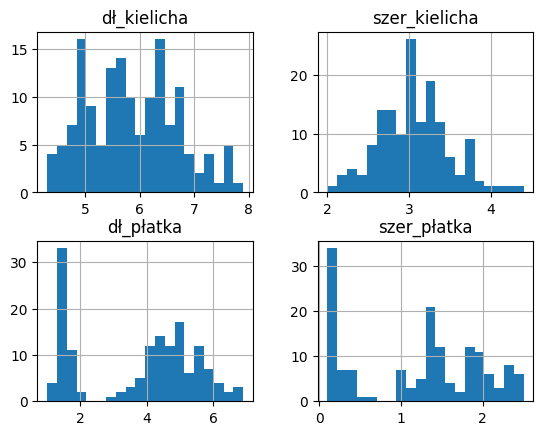

In [18]:
df.hist(bins=20)

# Histogramy opisujące każdy parametr kwiatów, w całej próbce. Podzielony na 20 zakresów. 
# Pokazuje ile kwiatów przypada na każdy zakres. Można wyczytać które cechy występują najczęściej.
# Na histogramie widać duży rozrzut wartości co dobitniej pokazuje, że trzeba rozpatrywać każdy gatunek osobno.

In [19]:
Markdown(f"""
## Wykres pudełkowy pokazuje że największy rozrzut wartości jest w długości płatka, a najmniejszy w szerokości kielicha
""")


## Wykres pudełkowy pokazuje że największy rozrzut wartości jest w długości płatka, a najmniejszy w szerokości kielicha


<Axes: >

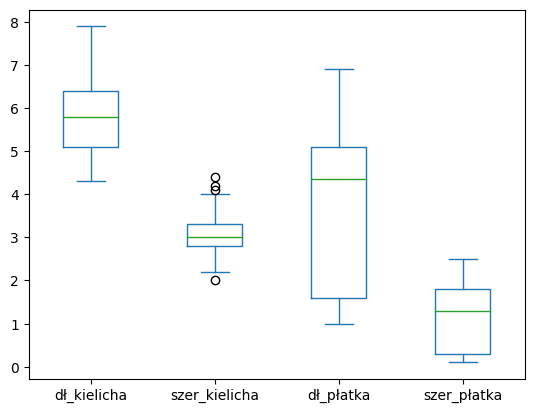

In [20]:
df.plot(kind='box')

# Wykres pudełkowy pokazuje że największy rozrzut wartości jest w długości płatka, a najmniejszy w szerokości kielicha

In [21]:
df[['dł_kielicha', 'szer_kielicha', 'dł_płatka',  'szer_płatka']].corr()

# Macierz korelacji pokazuje, że najbardziej ze sobą są skorelowane szerokość płatka i długość płatka, a najmniej długość płatka i szerokość kielicha

,dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
dł_kielicha,1.000000,-0.109369,0.871754,0.817954
szer_kielicha,-0.109369,1.000000,-0.420516,-0.356544
dł_płatka,0.871754,-0.420516,1.000000,0.962757
szer_płatka,0.817954,-0.356544,0.962757,1.000000


## Iris-setosa

In [22]:
# Oddzieliłem podzbiór kwiatów Iris-Setosa i utworzyłem osobny DataFrame

setosa= df.iloc[0: 50].copy()

setosa.sample(10)

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
32,Iris-setosa,5.2,4.1,1.5,0.1
8,Iris-setosa,4.4,2.9,1.4,0.2
19,Iris-setosa,5.1,3.8,1.5,0.3
0,Iris-setosa,5.1,3.5,1.4,0.2
42,Iris-setosa,4.4,3.2,1.3,0.2
46,Iris-setosa,5.1,3.8,1.6,0.2
30,Iris-setosa,4.8,3.1,1.6,0.2
9,Iris-setosa,4.9,3.1,1.5,0.1
10,Iris-setosa,5.4,3.7,1.5,0.2
21,Iris-setosa,5.1,3.7,1.5,0.4


In [23]:
setosa.describe()

# Opis statystyczny kwiatów Iris-setosa

,dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
count,50.00000,50.000000,50.000000,50.00000
mean,5.00600,3.418000,1.464000,0.24400
std,0.35249,0.381024,0.173511,0.10721
min,4.30000,2.300000,1.000000,0.10000
25%,4.80000,3.125000,1.400000,0.20000
50%,5.00000,3.400000,1.500000,0.20000
75%,5.20000,3.675000,1.575000,0.30000
max,5.80000,4.400000,1.900000,0.60000


In [24]:
Markdown(f"""
## Histogramy parametrów dla tego gatunku
""")


## Histogramy parametrów dla tego gatunku


array([[<Axes: title={'center': 'dł_kielicha'}>,
        <Axes: title={'center': 'szer_kielicha'}>],
       [<Axes: title={'center': 'dł_płatka'}>,
        <Axes: title={'center': 'szer_płatka'}>]], dtype=object)

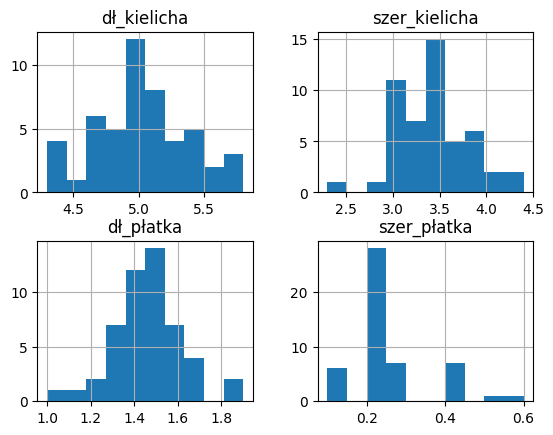

In [25]:
setosa.hist(bins=10)

<Axes: >

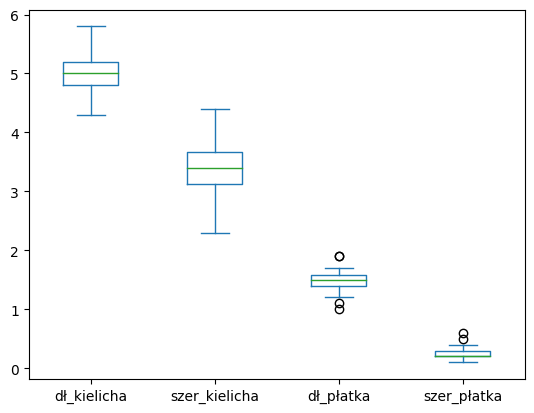

In [26]:
setosa.plot(kind='box')

In [27]:
setosa['śr_dł_kielicha'] = 5.006 
setosa['śr_dł_płatka'] = 1.464
setosa.sample()

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka,śr_dł_kielicha,śr_dł_płatka
14,Iris-setosa,5.8,4.0,1.2,0.2,5.006,1.464


## Z tego gatunku można wydzielić unikatowe okazy

In [28]:
# Postanowiłem wydzielić z grupy kwiaty najbardziej unikatowe. 
# Jako kryterium przyjąłem że każda opisywana cecha musi być większa bądź równa średniej dla całego zbioru

def unikatowość(dł_kielicha, dł_płatka, szer_kielicha, szer_płatka):
    if dł_kielicha >= 5.006 and dł_płatka >= 1.464 and szer_kielicha >= 3.418 and szer_płatka >= 0.244:
        return 'Unikatowy'
    else:
        return 'Pospolity'

setosa['unikatowość'] = setosa.apply(lambda row: unikatowość(row['dł_kielicha'], row['dł_płatka'], row['szer_kielicha'], row['szer_płatka']), axis=1)

# Użyłem komendy .sample(), żeby się krócej przewijało

setosa.sample(10)

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka,śr_dł_kielicha,śr_dł_płatka,unikatowość
27,Iris-setosa,5.2,3.5,1.5,0.2,5.006,1.464,Pospolity
8,Iris-setosa,4.4,2.9,1.4,0.2,5.006,1.464,Pospolity
28,Iris-setosa,5.2,3.4,1.4,0.2,5.006,1.464,Pospolity
49,Iris-setosa,5.0,3.3,1.4,0.2,5.006,1.464,Pospolity
10,Iris-setosa,5.4,3.7,1.5,0.2,5.006,1.464,Pospolity
37,Iris-setosa,4.9,3.1,1.5,0.1,5.006,1.464,Pospolity
3,Iris-setosa,4.6,3.1,1.5,0.2,5.006,1.464,Pospolity
12,Iris-setosa,4.8,3.0,1.4,0.1,5.006,1.464,Pospolity
25,Iris-setosa,5.0,3.0,1.6,0.2,5.006,1.464,Pospolity
48,Iris-setosa,5.3,3.7,1.5,0.2,5.006,1.464,Pospolity


In [29]:
# Oddzieliłem podzbiór unikatów z próbki

setosa_unikaty = setosa[setosa['unikatowość'] == 'Unikatowy']

setosa_unikaty

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka,śr_dł_kielicha,śr_dł_płatka,unikatowość
5,Iris-setosa,5.4,3.9,1.7,0.4,5.006,1.464,Unikatowy
15,Iris-setosa,5.7,4.4,1.5,0.4,5.006,1.464,Unikatowy
18,Iris-setosa,5.7,3.8,1.7,0.3,5.006,1.464,Unikatowy
19,Iris-setosa,5.1,3.8,1.5,0.3,5.006,1.464,Unikatowy
21,Iris-setosa,5.1,3.7,1.5,0.4,5.006,1.464,Unikatowy
44,Iris-setosa,5.1,3.8,1.9,0.4,5.006,1.464,Unikatowy


In [30]:
setosa_unikaty.describe()

,dł_kielicha,szer_kielicha,dł_płatka,szer_płatka,śr_dł_kielicha,śr_dł_płatka
count,6.000000,6.000000,6.000000,6.000000,6.000,6.000000e+00
mean,5.350000,3.900000,1.633333,0.366667,5.006,1.464000e+00
std,0.294958,0.252982,0.163299,0.051640,0.000,2.432377e-16
min,5.100000,3.700000,1.500000,0.300000,5.006,1.464000e+00
25%,5.100000,3.800000,1.500000,0.325000,5.006,1.464000e+00
50%,5.250000,3.800000,1.600000,0.400000,5.006,1.464000e+00
75%,5.625000,3.875000,1.700000,0.400000,5.006,1.464000e+00
max,5.700000,4.400000,1.900000,0.400000,5.006,1.464000e+00


### Podsumowanie Iris-setosa

##### Anazlize wykonane na próbce 50 kwiatów. Iris-setosa gabarytowo są najmniejszym przedstawicielem Irysów. Za to jako jedyne mają szerszy kielich niż długość płatka. Można to z łatwością wyczytać z wykresu pudełkowego.
##### Najważniejsce cechy opisujące zbiór kwiatów:
1. Średnie: dł. kielicha: 5.006, szer. kielicha: 3.418, dł. płatka: 1.464, szer. płatka: 0.24400
2. Najmniejsze uzyskane wartości: dł. kielicha: 4.3,	szer. kielicha: 2.3, dł. płatka: 1, szer. płatka: 0.1
3. Największe uzyskane wasrtości: dł. kielicha: 5.8, szer. kielicha: 4.4,	dł. płatka: 1.9, szer. płatka: 0.6
4. Z histogramu możemy wyczytać że najwięcej kwiatów ma dł. kileicha w okolicach 4.9 a 5.2, jeśli chodzi o szer. kielicha jest to między 2.9 a 3.5. W przypadku płatków te wartości są między 1.3 a 1.6 oraz 0.2 a 0.3
5. Wskaźnik odchylenia standardowego pokazuje nam, że ta grupa kwiatów jest najmniej zróżnicowana. Kwiaty gabarytowo są podobne do siebie.

##### Jeśli wydzielimy z grupy najbardziej unikatowe kwiaty które posiadają wszystkie cechy równe lub wyższe od średniej, to będzie ich 6


## Iris-versicolor

In [31]:
versicolor = df.iloc[50: 100].copy()

# Oddzielono podzbiór kwiatów Iris-Versicolor

versicolor.sample(10)

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
87,Iris-versicolor,6.3,2.3,4.4,1.3
57,Iris-versicolor,4.9,2.4,3.3,1.0
94,Iris-versicolor,5.6,2.7,4.2,1.3
66,Iris-versicolor,5.6,3.0,4.5,1.5
68,Iris-versicolor,6.2,2.2,4.5,1.5
64,Iris-versicolor,5.6,2.9,3.6,1.3
96,Iris-versicolor,5.7,2.9,4.2,1.3
78,Iris-versicolor,6.0,2.9,4.5,1.5
93,Iris-versicolor,5.0,2.3,3.3,1.0
99,Iris-versicolor,5.7,2.8,4.1,1.3


In [32]:
versicolor.describe()

# Opis statystyczny kwiatów Iris-versivolor

,dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
count,50.000000,50.000000,50.000000,50.000000
mean,5.936000,2.770000,4.260000,1.326000
std,0.516171,0.313798,0.469911,0.197753
min,4.900000,2.000000,3.000000,1.000000
25%,5.600000,2.525000,4.000000,1.200000
50%,5.900000,2.800000,4.350000,1.300000
75%,6.300000,3.000000,4.600000,1.500000
max,7.000000,3.400000,5.100000,1.800000


In [33]:
Markdown(f"""
## Histogramy parametrów dla tego gatunku
""")


## Histogramy parametrów dla tego gatunku


array([[<Axes: title={'center': 'dł_kielicha'}>,
        <Axes: title={'center': 'szer_kielicha'}>],
       [<Axes: title={'center': 'dł_płatka'}>,
        <Axes: title={'center': 'szer_płatka'}>]], dtype=object)

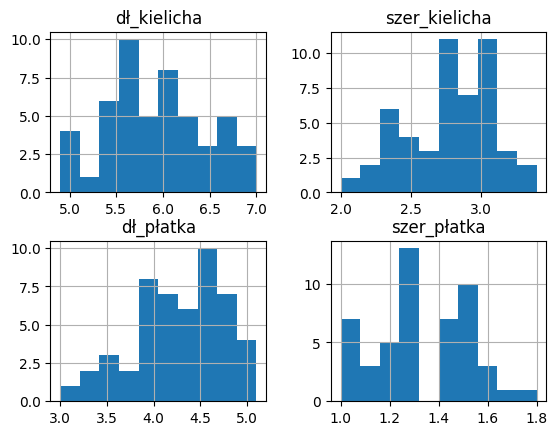

In [34]:
versicolor.hist(bins=10)

<Axes: >

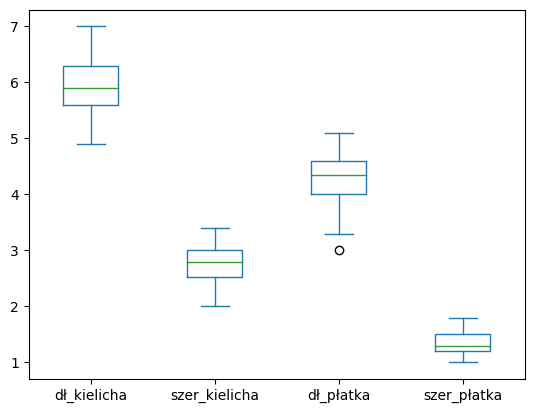

In [35]:
versicolor.plot(kind='box')

## Z tego gatunku można wydzielić unikatowe okazy

In [36]:
# Postanowiłem wydzielić z grupy kwiaty najbardziej unikatowe. 
# Jako kryterium przyjąłem że każda opisywana cecha musi być większa bądź równa średniej całego zbioru


def unikatowość(dł_kielicha, dł_płatka, szer_kielicha, szer_płatka):
    if dł_kielicha >= 5.936 and dł_płatka >= 4.26 and szer_kielicha >= 2.77 and szer_płatka >= 1.326:
        return 'Unikatowy'
    else:
        return 'Pospolity'

versicolor['unikatowość'] = versicolor.apply(lambda row: unikatowość(row['dł_kielicha'], row['dł_płatka'], row['szer_kielicha'], row['szer_płatka']), axis=1)

# Użyłem komendy .sample(), żeby się krócej przewijało

versicolor.sample(10)

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka,unikatowość
58,Iris-versicolor,6.6,2.9,4.6,1.3,Pospolity
53,Iris-versicolor,5.5,2.3,4.0,1.3,Pospolity
89,Iris-versicolor,5.5,2.5,4.0,1.3,Pospolity
59,Iris-versicolor,5.2,2.7,3.9,1.4,Pospolity
78,Iris-versicolor,6.0,2.9,4.5,1.5,Unikatowy
68,Iris-versicolor,6.2,2.2,4.5,1.5,Pospolity
69,Iris-versicolor,5.6,2.5,3.9,1.1,Pospolity
76,Iris-versicolor,6.8,2.8,4.8,1.4,Unikatowy
79,Iris-versicolor,5.7,2.6,3.5,1.0,Pospolity
55,Iris-versicolor,5.7,2.8,4.5,1.3,Pospolity


In [37]:
# Oddzieliłem podzbiór unikatów z próbki

versicolor_unikaty = versicolor[versicolor['unikatowość'] == 'Unikatowy']

versicolor_unikaty

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka,unikatowość
50,Iris-versicolor,7.0,3.2,4.7,1.4,Unikatowy
51,Iris-versicolor,6.4,3.2,4.5,1.5,Unikatowy
52,Iris-versicolor,6.9,3.1,4.9,1.5,Unikatowy
54,Iris-versicolor,6.5,2.8,4.6,1.5,Unikatowy
56,Iris-versicolor,6.3,3.3,4.7,1.6,Unikatowy
63,Iris-versicolor,6.1,2.9,4.7,1.4,Unikatowy
65,Iris-versicolor,6.7,3.1,4.4,1.4,Unikatowy
75,Iris-versicolor,6.6,3.0,4.4,1.4,Unikatowy
76,Iris-versicolor,6.8,2.8,4.8,1.4,Unikatowy
77,Iris-versicolor,6.7,3.0,5.0,1.7,Unikatowy


In [38]:
versicolor_unikaty.describe()


,dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
count,14.000000,14.000000,14.000000,14.000000
mean,6.485714,3.057143,4.642857,1.485714
std,0.339359,0.178516,0.178516,0.094926
min,6.000000,2.800000,4.400000,1.400000
25%,6.150000,2.925000,4.500000,1.400000
50%,6.550000,3.050000,4.650000,1.500000
75%,6.700000,3.175000,4.700000,1.500000
max,7.000000,3.400000,5.000000,1.700000


## Podsumowanie Iris-versicolor
##### Anazlize wykonane na próbce 50 kwiatów. Iris-versicolor gabarytowo są środkowymi przedstawicielami Irysów.
##### Najważniejsce cechy opisujące zbiór kwiatów:
1. Średnie: dł. kielicha: 5.936, szer. kielicha: 2.77, dł. płatka: 4.26, szer. płatka: 1.326
3. Najmniejsze uzyskane wartości: dł. kielicha: 4.9, szer. kielicha: 2, dł. płatka: 3, szer. płatka: 1
5. Największe uzyskane wasrtości: dł. kielicha: 7, szer. kielicha: 3.4, dł. płatka: 5.1, szer. płatka: 1.8
6. Z histogramu możemy wyczytać że najwięcej kwiatów ma dł. kileicha w okolicach 5.4 a 6.3, jeśli chodzi o szer. kielicha jest to między 2.7 a 3.1. W przypadku płatków te wartości są między 3.9 a 4.8 oraz 1.3 albo 1.5

##### Jeśli wydzielimy z grupy najbardziej unikatowe kwiaty które posiadają wszystkie cechy równe lub wyższe od średniej, to będzie ich 14

## Iris-virginica

In [39]:
#Oddzielono podzbió kwiatów Iris-virginica

virginica = df.iloc[100: 150].copy()

virginica.sample(10)

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
113,Iris-virginica,5.7,2.5,5.0,2.0
112,Iris-virginica,6.8,3.0,5.5,2.1
106,Iris-virginica,4.9,2.5,4.5,1.7
124,Iris-virginica,6.7,3.3,5.7,2.1
122,Iris-virginica,7.7,2.8,6.7,2.0
146,Iris-virginica,6.3,2.5,5.0,1.9
130,Iris-virginica,7.4,2.8,6.1,1.9
137,Iris-virginica,6.4,3.1,5.5,1.8
129,Iris-virginica,7.2,3.0,5.8,1.6
108,Iris-virginica,6.7,2.5,5.8,1.8


In [40]:
virginica.describe()

#Opis statystyczny kwiatów Iris-virginica

,dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
count,50.00000,50.000000,50.000000,50.00000
mean,6.58800,2.974000,5.552000,2.02600
std,0.63588,0.322497,0.551895,0.27465
min,4.90000,2.200000,4.500000,1.40000
25%,6.22500,2.800000,5.100000,1.80000
50%,6.50000,3.000000,5.550000,2.00000
75%,6.90000,3.175000,5.875000,2.30000
max,7.90000,3.800000,6.900000,2.50000


In [41]:
Markdown(f"""
## Histogramy parametrów dla tego gatunku
""")



## Histogramy parametrów dla tego gatunku


array([[<Axes: title={'center': 'dł_kielicha'}>,
        <Axes: title={'center': 'szer_kielicha'}>],
       [<Axes: title={'center': 'dł_płatka'}>,
        <Axes: title={'center': 'szer_płatka'}>]], dtype=object)

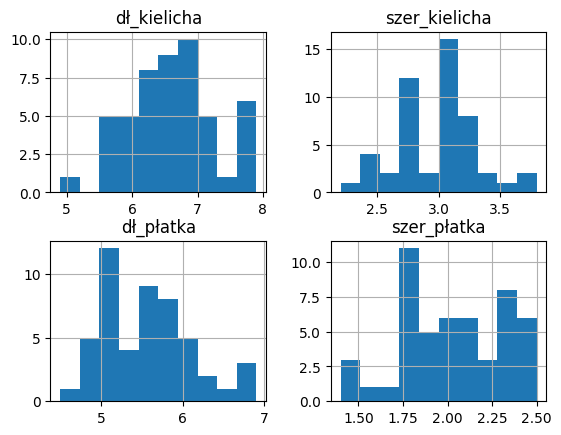

In [42]:
virginica.hist(bins=10)

<Axes: >

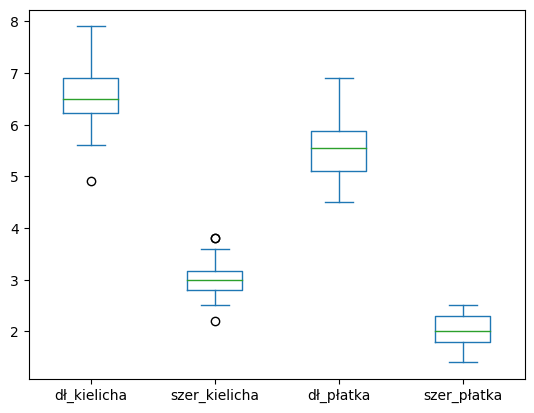

In [43]:
virginica.plot(kind='box')

## Z tego gatunku można wydzielić unikatowe okazy

In [44]:
# Postanowiłem wydzielić z grupy kwiaty najbardziej unikatowe. 
# Jako kryterium przyjąłem że każda opisywana cecha musi być większa bądź równa średniej całego zbioru


def unikatowość(dł_kielicha, dł_płatka, szer_kielicha, szer_płatka):
    if dł_kielicha >= 6.588 and dł_płatka >= 5.552 and szer_kielicha >= 2.974 and szer_płatka >= 2.026:
        return 'Unikatowy'
    else:
        return 'Pospolity'

virginica['unikatowość'] = virginica.apply(lambda row: unikatowość(row['dł_kielicha'], row['dł_płatka'], row['szer_kielicha'], row['szer_płatka']), axis=1)

# Użyłem komendy .sample(), żeby się krócej przewijało

virginica.sample(10) 

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka,unikatowość
124,Iris-virginica,6.7,3.3,5.7,2.1,Unikatowy
104,Iris-virginica,6.5,3.0,5.8,2.2,Pospolity
103,Iris-virginica,6.3,2.9,5.6,1.8,Pospolity
102,Iris-virginica,7.1,3.0,5.9,2.1,Unikatowy
122,Iris-virginica,7.7,2.8,6.7,2.0,Pospolity
110,Iris-virginica,6.5,3.2,5.1,2.0,Pospolity
100,Iris-virginica,6.3,3.3,6.0,2.5,Pospolity
115,Iris-virginica,6.4,3.2,5.3,2.3,Pospolity
105,Iris-virginica,7.6,3.0,6.6,2.1,Unikatowy
101,Iris-virginica,5.8,2.7,5.1,1.9,Pospolity


In [45]:
# Oddzieliłem podzbiór unikatów z próbki

virginica_unikaty = virginica[virginica['unikatowość'] == 'Unikatowy']

virginica_unikaty

,klasa (class),dł_kielicha,szer_kielicha,dł_płatka,szer_płatka,unikatowość
102,Iris-virginica,7.1,3.0,5.9,2.1,Unikatowy
105,Iris-virginica,7.6,3.0,6.6,2.1,Unikatowy
109,Iris-virginica,7.2,3.6,6.1,2.5,Unikatowy
117,Iris-virginica,7.7,3.8,6.7,2.2,Unikatowy
120,Iris-virginica,6.9,3.2,5.7,2.3,Unikatowy
124,Iris-virginica,6.7,3.3,5.7,2.1,Unikatowy
135,Iris-virginica,7.7,3.0,6.1,2.3,Unikatowy
140,Iris-virginica,6.7,3.1,5.6,2.4,Unikatowy
143,Iris-virginica,6.8,3.2,5.9,2.3,Unikatowy
144,Iris-virginica,6.7,3.3,5.7,2.5,Unikatowy


In [46]:
virginica_unikaty.describe()

,dł_kielicha,szer_kielicha,dł_płatka,szer_płatka
count,10.000000,10.000000,10.000000,10.000000
mean,7.110000,3.250000,6.000000,2.280000
std,0.420185,0.267706,0.382971,0.154919
min,6.700000,3.000000,5.600000,2.100000
25%,6.725000,3.025000,5.700000,2.125000
50%,7.000000,3.200000,5.900000,2.300000
75%,7.500000,3.300000,6.100000,2.375000
max,7.700000,3.800000,6.700000,2.500000


## Podsumowanie Iris-versicolor
##### Anazlize wykonane na próbce 50 kwiatów. Iris-virginica są największymi przedstawicielami Irysów. 
##### Najważniejsce cechy opisujące zbiór kwiatów:
1. Średnie: dł. kielicha: 6.59, szer. kielicha: 2.97, dł. płatka: 5.55, szer. płatka: 2.03
2. Najmniejsze uzyskane wartości: dł. kielicha: 4.9, szer. kielicha: 2.2, dł. płatka: 4.5, szer. płatka: 1.4
3. Największe uzyskane wasrtości: dł. kielicha: 7.9, szer. kielicha: 3.8, dł. płatka: 6.9, szer. płatka: 2.5
4. Z histogramu możemy wyczytać że najwięcej kwiatów ma dł. kileicha w okolicach 6.1 a 7, jeśli chodzi o szer. kielicha jest to między 2.8 a 3.1. W przypadku płatków te wartości są między 5.1 a 5.9 oraz 1.75 a 2.5
5. Wskaźnik odchylenia standardowego pokauje nam, że ta grupa kwiatów jest najbardziej zróźnicowana gabaytowo

#### Jeśli wydzielimy z grupy najbardziej unikatowe kwiaty które posiadają wszystkie cechy równe lub wyższe od średniej, to będzie ich 10

In [47]:
!jupyter nbconvert 25__zadanie_domowe__modul_4MK_1 --to html --no-input --no-prompt

[NbConvertApp] Converting notebook 25__zadanie_domowe__modul_4MK_1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 541058 bytes to 25__zadanie_domowe__modul_4MK_1.html
